In [36]:
import pandas as pd                    # for data manipulation
import statsmodels.formula.api as smf  # for linear regression and logistic regression
from scipy.stats import norm, binom    # for probability calculations

In [37]:
import math

Submitted by Rob Hefferon, Rebecca Xi, María Gistau Mur, Loanne Merlin, Shunichiro Nakamura, Jens Odegard, McKinley Reynolds.

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Problem #1: Day Passes at the Foundry**

The Foundry is a co-working space in Kendall Square with 30 hot desks. It sells exactly 30 monthly memberships (one per desk), so every member is guaranteed a desk on any business day. Not every member comes in every day, however. Over the past 250 business days, The Foundry has recorded the number of members who badged in each day. The data is in coworking_showups.csv.

Because desks often sit empty, management is considering selling day passes to non-members. Under
the proposed policy, every morning at 8:00 a.m. The Foundry sells k day passes at 35 dollars each. (There is
a long waitlist of people who want day passes, so all k passes always sell.)

Day-pass holders arrive at
8:00 a.m. and each takes a desk, leaving $30 − k$ desks for members. Members arrive later in the
morning. If more than $30 − k$ members show up, the extra members are “bumped”: they are sent to a
partner co-working space across the street, which costs The Foundry $120 per bumped member (the
partner’s fee plus an estimated goodwill cost).

a) Using Python, plot the empirical distribution (histogram) of the daily number of
members who showed up, and report the mean, the standard deviation, the median, and the
90th percentile. Based on the data, what is the probability that all 30 desks are occupied on a
given day? What is the probability that at least 5 desks are empty?

In [39]:
foundry_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/coworking_showups.csv")

In [40]:
foundry_data.head()

,date,day_of_week,members_showed_up
0,2025-09-22,Monday,25
1,2025-09-23,Tuesday,24
2,2025-09-24,Wednesday,26
3,2025-09-25,Thursday,24
4,2025-09-26,Friday,22


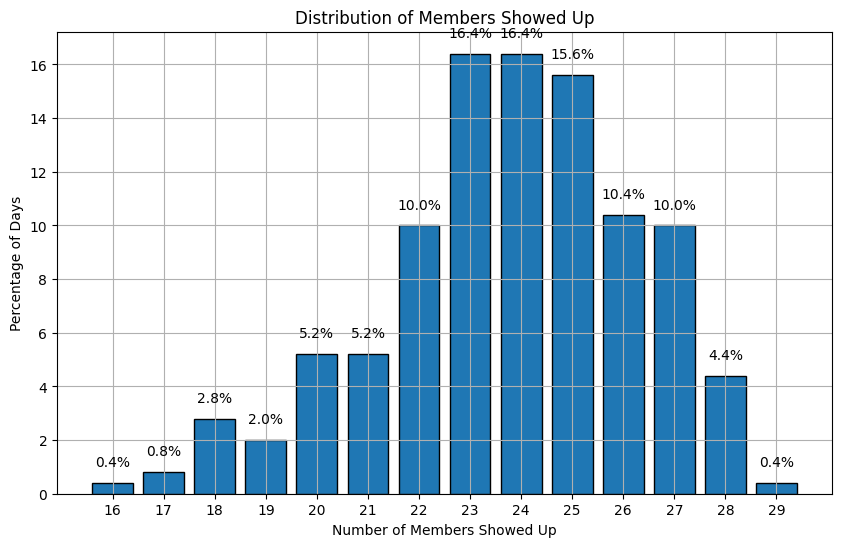

In [41]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# Calculate the total number of observations
total_observations = len(foundry_data['members_showed_up'])

# Create a list of weights where each weight is 1/total_observations * 100
# This scales the histogram heights to represent percentages
weights = np.ones_like(foundry_data['members_showed_up']) / total_observations * 100

# Determine the range for discrete bins
min_members = foundry_data['members_showed_up'].min()
max_members = foundry_data['members_showed_up'].max()

# Create bins that separate each integer value (e.g., 19.5, 20.5, 21.5, etc.)
bins = np.arange(min_members - 0.5, max_members + 1.5, 1)

fig, ax = plt.subplots(figsize=(10, 6))
counts, bin_edges, patches = ax.hist(foundry_data['members_showed_up'], bins=bins, weights=weights, edgecolor='black', rwidth=0.8)
ax.set_title('Distribution of Members Showed Up')
ax.set_xlabel('Number of Members Showed Up')
ax.set_ylabel('Percentage of Days')

# Set x-axis ticks to be integers for clarity
ax.set_xticks(np.arange(min_members, max_members + 1, 1))

ax.grid(True) # Add a grid for better readability

# Add percentage labels above each bar
for count, bin_edge, patch in zip(counts, bin_edges, patches):
    if count > 0: # Only label bars that have a height > 0
        x = patch.get_x() + patch.get_width() / 2 # Center of the bar
        y = patch.get_height() # Height of the bar (percentage)
        ax.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom') # Add label slightly above the bar

plt.show()

In [42]:
mean_members = foundry_data['members_showed_up'].mean()
std_dev_members = foundry_data['members_showed_up'].std()
median_members = foundry_data['members_showed_up'].median()
pct_90_members = foundry_data['members_showed_up'].quantile(0.90)

print(f"Mean of members showed up: {mean_members:.2f}")
print(f"Standard deviation of members showed up: {std_dev_members:.2f}")
print(f"Median of members showed up: {median_members:.2f}")
print(f"90th percentile of members showed up: {pct_90_members:.2f}")

Mean of members showed up: 23.78
Standard deviation of members showed up: 2.50
Median of members showed up: 24.00
90th percentile of members showed up: 27.00


**Probability that all 30 desks are occupied on any given day:** 0

$P(30)=0$ because there is no day in the historical data where all 30 people showed up.

**Probability that at least 5 desks are empty:** 74.8%

$1-(P(26)+P(27)+P(28)+P(29)+P(30) )$

$1-(0.104+0.1+0.044+0.004+0) = .748$

b) Suppose The Foundry sells $k = 3$ one-day passes. Using the empirical distribution
from part (a), compute by hand the expected number of bumped members per day. Repeat
for k = 4.

Expected Bump ($k=3$): $0(3) +0.004(2)+0.044(1) = 0.052$

In [43]:
0*3+0.004*2+0.044*1

0.052

Expected Bump ($k=4$): $0(4) + 0.004(3)+0.044(2)+0.1(1) = 0.2$

In [44]:
0*4+0.004*3+0.044*2+0.1*1

0.2

Management’s initial policy is that, on average, no more than 1 member should be
bumped every 10 business days. What is the largest number of day passes that satisfies this
policy?

The largest number of day passes that, on average, bumps no more than 1 member every 10 days is the same as the largest number of day passes that, on average bumps no more than 0.1 members every 1 day. Therefore, the maximum number of day passes that fits this requirement is three passes ($k=3$), which will bump on average 0.052 people per day or 0.52 people every 10 days.

c) Now let’s take profit into account. The expected daily profit from the day-pass
program is

Profit(k) = 35 × k − 120 × (expected number of bumped members per day).

Using Python, compute Profit($k$) for k = 0, 1, …, 10 and find the k that maximizes it. For that k,
report the expected daily profit, the expected number of bumped members per day, and the
probability that at least one member is bumped on a given day.

In [45]:
# @title
import pandas as pd

def calculate_profit_for_df(data_frame, k_range=range(11)):
    profit_results_list = []
    for k in k_range:
        available_desks_for_members = 30 - k
        bumped_members_daily = (data_frame['members_showed_up'] - available_desks_for_members).clip(lower=0)
        average_bumped_per_day = bumped_members_daily.mean()
        profit_k = (35 * k) - (120 * average_bumped_per_day)
        profit_results_list.append({
            '# Day Passes (k)': k,
            'Expected Daily Profit': profit_k,
            'Expected Bumped Members Per Day': average_bumped_per_day
        })
    return pd.DataFrame(profit_results_list)

# Calculate profits for k = 0, 1, ..., 10
profit_df = calculate_profit_for_df(foundry_data)

# Display the profit_df to show the results
display(profit_df)

,# Day Passes (k),Expected Daily Profit,Expected Bumped Members Per Day
0,0,0.00,0.000
1,1,35.00,0.000
2,2,69.52,0.004
3,3,98.76,0.052
4,4,116.00,0.200
5,5,120.76,0.452
6,6,106.80,0.860
7,7,73.16,1.432
8,8,19.84,2.168
9,9,-45.48,3.004


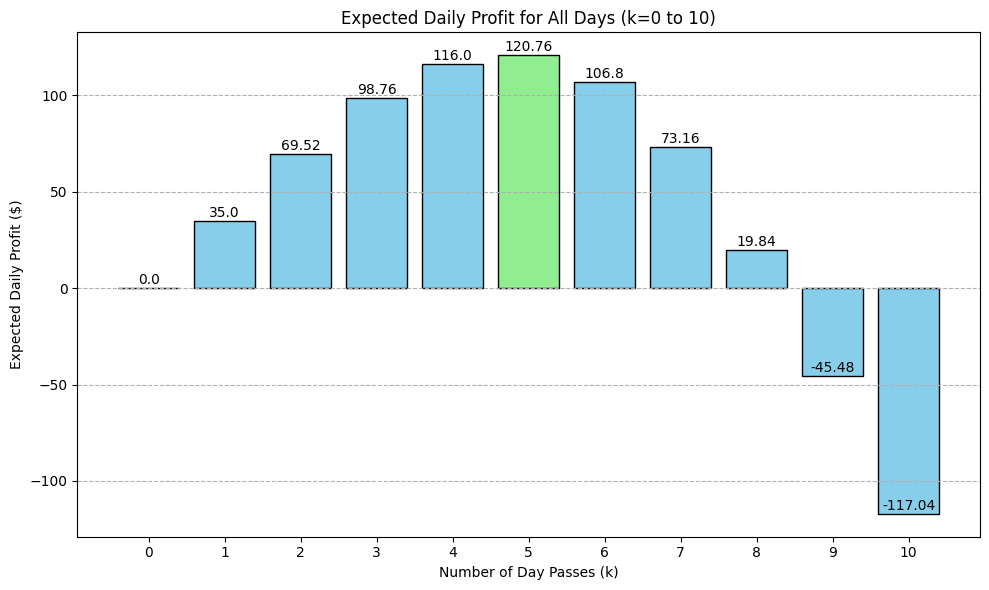

In [46]:
# @title
import matplotlib.pyplot as plt
import pandas as pd # Added for robustness, although not strictly used in plot_profit_histogram itself

def plot_profit_histogram(profit_df, title):
    max_profit_k = profit_df.loc[profit_df['Expected Daily Profit'].idxmax(), '# Day Passes (k)']

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['skyblue' if k != max_profit_k else 'lightgreen' for k in profit_df['# Day Passes (k)'].values]
    bars = ax.bar(profit_df['# Day Passes (k)'], profit_df['Expected Daily Profit'], color=colors, edgecolor='black')

    ax.set_title(title)
    ax.set_xlabel('Number of Day Passes (k)')
    ax.set_ylabel('Expected Daily Profit ($)')
    ax.set_xticks(range(0, 11))
    ax.grid(axis='y', linestyle='--')

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# Assuming profit_df has been calculated in a previous cell (ff3575f9)
plot_profit_histogram(profit_df, 'Expected Daily Profit for All Days (k=0 to 10)')

In [47]:
# @title
import pandas as pd

# Assuming profit_df is already defined from previous cells (ff3575f9).

max_profit_k = profit_df.loc[profit_df['Expected Daily Profit'].idxmax(), '# Day Passes (k)']

# 1. Expected Daily Profit for max_profit_k
expected_daily_profit_at_max_k = profit_df.loc[profit_df['# Day Passes (k)'] == max_profit_k, 'Expected Daily Profit'].iloc[0]

# 2. Expected Number of Bumped Members per Day for max_profit_k
# This information is directly available in profit_df
expected_bumped_per_day_at_max_k = profit_df.loc[profit_df['# Day Passes (k)'] == max_profit_k, 'Expected Bumped Members Per Day'].iloc[0]

# 3. Probability that at least one member is bumped on a given day for max_profit_k
available_desks_for_members_at_max_k = 30 - max_profit_k

# Count days where members showed up more than available desks
# This calculation needs the original foundry_data, which is assumed to be loaded
days_with_bumped_members = (foundry_data['members_showed_up'] > available_desks_for_members_at_max_k).sum()

# Calculate the probability
probability_at_least_one_bumped = days_with_bumped_members / len(foundry_data)

print(f"For k = {int(max_profit_k)} (profit-maximizing value):")
print(f"  Expected Daily Profit: ${expected_daily_profit_at_max_k:.2f}")
print(f"  Expected Number of Bumped Members per Day: {expected_bumped_per_day_at_max_k:.2f}")
print(f"  Probability that at least one member is bumped on a given day: {probability_at_least_one_bumped:.2%}")

For k = 5 (profit-maximizing value):
  Expected Daily Profit: $120.76
  Expected Number of Bumped Members per Day: 0.45
  Probability that at least one member is bumped on a given day: 25.20%


For the profit-maximizing value $k=5$, the probability that at least one member is bumped on a given day is the same as the probability that there are fewer than five empty desks. This is the cumulative probability of 26-30 people showing up at the coworking space, which we already calculated as part of part (a) above. So it is 25.2%.



**d) The general manager argues "The average number of members who show up is
about 24. So if we sell 6 day passes, we still have 24 desks for members, and on average
nobody gets bumped.” Is there something wrong with the manager’s argument? Please
explain briefly using numbers from the data. Would you sell 6 day passes, financially
speaking?**

The probability that nobody will be bumped if we sell 6 passes is the same as 1 - the probability that at least 25 members show up. Adapting the calculation from Part 1.b, that probability is: $1-(P(25)+P(26)+P(27)+P(28)+P(29)+P(30) )$

$1-(0.004 +0.044 + 0.1 + 0.104+0.156) = .592$


Therefore, the manager is right that on average nobody will be bumped on a given day when we sell 6 passes.

However, the profit equation shows that selling a sixth day pass would be a bad financial decision because, while on the average day there is less than a 50% chance of someone being bumped, the marginal financial cost of \$120 for each person who is bumped outweighs the financial benefit of the marginal additional day pass sold at \$35 per seat. This can be seen by running the profit equation for $k=5$ and $k=6$, showing that the resulting profit for $k=6$ (\$106.80) is actually less than that for $k=5$ (\$120.76).


In [48]:
35*6-(120)*(.156*1+(.104*2+.1*3+0.044*4+.004*5+0*6))

106.8

In [49]:
35*5-(120)*(.104*1+.1*2+.044*3+.004*4+0*5)

120.75999999999999

e) The Foundry’s data analyst suspects that attendance is different on Fridays. Using
Python, compute the average number of members who showed up on each day of the week.
Is she right?
She proposes a day-specific policy: sell kFri passes on Fridays and kMTWT passes on Monday
through Thursday. Find the profit-maximizing kFri and kMTWT (evaluate each on the
corresponding subset of the data), and compute how much more expected profit per year
(250 business days) the day-specific policy generates compared to the single-k policy of part
(c).

In [50]:
foundry_data['MTWT'] = foundry_data['day_of_week'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday'])
foundry_data['Fri'] = foundry_data['day_of_week'] == 'Friday'
foundry_data.head()

,date,day_of_week,members_showed_up,MTWT,Fri
0,2025-09-22,Monday,25,True,False
1,2025-09-23,Tuesday,24,True,False
2,2025-09-24,Wednesday,26,True,False
3,2025-09-25,Thursday,24,True,False
4,2025-09-26,Friday,22,False,True


In [51]:
df_MTWT=foundry_data[foundry_data['MTWT']==True]
df_MTWT.head()

,date,day_of_week,members_showed_up,MTWT,Fri
0,2025-09-22,Monday,25,True,False
1,2025-09-23,Tuesday,24,True,False
2,2025-09-24,Wednesday,26,True,False
3,2025-09-25,Thursday,24,True,False
5,2025-09-29,Monday,27,True,False


In [52]:
df_Fri=foundry_data[foundry_data['Fri']==True]
df_Fri.head()

,date,day_of_week,members_showed_up,MTWT,Fri
4,2025-09-26,Friday,22,False,True
9,2025-10-03,Friday,23,False,True
14,2025-10-10,Friday,25,False,True
19,2025-10-17,Friday,20,False,True
24,2025-10-24,Friday,18,False,True


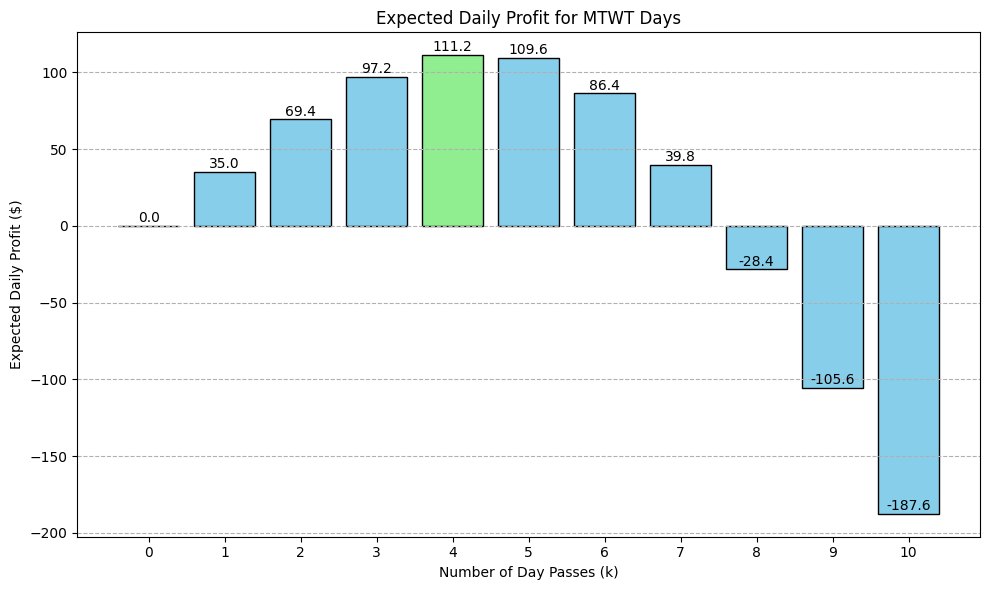

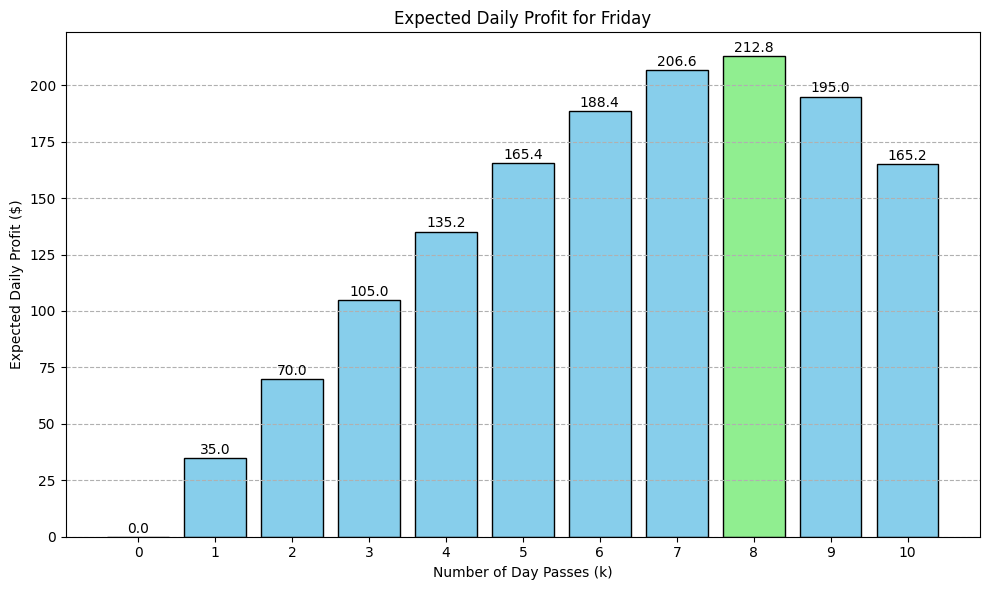


--- MTWT Days ---
Profit-maximizing k for MTWT days: 4
Expected Daily Profit for MTWT days: $111.20

--- Friday ---
Profit-maximizing k for Friday: 8
Expected Daily Profit for Friday: $212.80


In [53]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

def calculate_profit_for_df(data_frame, k_range=range(11)):
    profit_results_list = []
    for k in k_range:
        available_desks_for_members = 30 - k
        bumped_members_daily = (data_frame['members_showed_up'] - available_desks_for_members).clip(lower=0)
        average_bumped_per_day = bumped_members_daily.mean()
        profit_k = (35 * k) - (120 * average_bumped_per_day)
        profit_results_list.append({
            '# Day Passes (k)': k,
            'Expected Daily Profit': profit_k,
            'Expected Bumped Members Per Day': average_bumped_per_day
        })
    return pd.DataFrame(profit_results_list)

def plot_profit_histogram(profit_df, title):
    max_profit_k = profit_df.loc[profit_df['Expected Daily Profit'].idxmax(), '# Day Passes (k)']

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['skyblue' if k != max_profit_k else 'lightgreen' for k in profit_df['# Day Passes (k)']]
    bars = ax.bar(profit_df['# Day Passes (k)'], profit_df['Expected Daily Profit'], color=colors, edgecolor='black')

    ax.set_title(title)
    ax.set_xlabel('Number of Day Passes (k)')
    ax.set_ylabel('Expected Daily Profit ($)')
    ax.set_xticks(range(0, 11))
    ax.grid(axis='y', linestyle='--')

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# Calculate profits for MTWT days
profit_mtwt_df = calculate_profit_for_df(df_MTWT)

# Calculate profits for Friday
profit_fri_df = calculate_profit_for_df(df_Fri)

# Plot histograms
plot_profit_histogram(profit_mtwt_df, 'Expected Daily Profit for MTWT Days')
plot_profit_histogram(profit_fri_df, 'Expected Daily Profit for Friday')

# Additionally, print the profit-maximizing k and profit for each scenario
print("\n--- MTWT Days ---")
max_k_mtwt = profit_mtwt_df.loc[profit_mtwt_df['Expected Daily Profit'].idxmax()]
print(f"Profit-maximizing k for MTWT days: {int(max_k_mtwt['# Day Passes (k)'])}")
print(f"Expected Daily Profit for MTWT days: ${max_k_mtwt['Expected Daily Profit']:.2f}")

print("\n--- Friday ---")
max_k_fri = profit_fri_df.loc[profit_fri_df['Expected Daily Profit'].idxmax()]
print(f"Profit-maximizing k for Friday: {int(max_k_fri['# Day Passes (k)'])}")
print(f"Expected Daily Profit for Friday: ${max_k_fri['Expected Daily Profit']:.2f}")

The profit-maximizing number of day passes for kMTWT is 4. The expected daily profit for those passes would be \$111.20 per day. We are interested in the profit over the course of a year, which will be 50 weeks and 4 days (MTWT) per week. Therefore, it is \$22,240 of profit for kMTWT.

In [54]:
111.20*50*4

22240.0

The profit-maximizing number of day passes for kFri is 8. The expected daily profit for those passes would be $212.80. Over the course of a year (50 weeks, 1 day per week) the profit would be \$10,640.

In [55]:
212.80*50*1

10640.0

Together, this new policy is expected to bring in a profit of $32,880 each year.

In [56]:
22240+10640

32880

Under the non-day-specific policy in part (c) above, the expected profitability per day was 120.76 after selling k=4 passes. This yielded an annual expected profitability of \$30,190. This means that the day-specific policy is expected to drive \$2,690 more in profitability than the policy from part (c).

In [57]:
120.76*250

30190.0

In [58]:
32880-30190

2690

f) For each of the following three proposals, state whether the historical data in
coworkingshowups.csv alone is enough to estimate the proposal’s expected daily profit, and
explain why or why not in 2–3 sentences. (You do not need to compute anything.)

i) The partner space raises its fee, so that each bumped member now costs The Foundry
\$150 instead of \$120.

The cost that The Foundry pays for each bumped member does not impact the number of members who choose to show up. Therefore, the historical data *is* enough to estimate expected daily profit. One simply needs to update the profit equation to P(k)=35(k) - 150*(expected bumped members)

ii) The Foundry keeps its 30 desks but sells 5 additional memberships, for a total of 35
members, and continues to sell k day passes every morning.

The historical data is not enough to estimate the proposal's expected daily profit. We do not have historical data for how the distribution would shift with five additional passes so would need to run an experiment or build a model to update the "expected bumped members" variable of the equation.

iii) Members must reserve a desk through an app by 7:00 a.m.; at 8:00 a.m., every desk
that was not reserved is sold as a day pass.

Yes, the historical data is enough to calculate profitability, assuming that day passes are *only* sold at 8:00am (and no guest passes are sold in advance of the 7:00am cutoff). This new system would mean that no member is ever bumped, so the profitability equation for day passes would simplify to 35 * (30 - 'expected number of guests').

##**Problem #2: Optimizing Checkout Recommendations**

A large online retailer D.M.D is looking to redesign its checkout experience to increase sales. A natural
way to boost revenue at checkout is to recommend additional products that may go well with the
products you are already about to purchase. The team has two ideas on how to do this:


*   **Variant A:** Ask an LLM to generate complementary products to those in your cart. Although
highly personalized, this is slow and introduces additional latency that some customers may
not want to wait for.
*   **Variant B:** Show popular products from categories that are frequently co-purchased with the
items in the user’s cart. The suggestions are more generic, but they render instantly.

The status quo right now is that there’s nothing on the cart page at all. The historical benchmark for
revenue per visitor is **$18.28**.

In the past 10 days, D.M.D experimented with Variant A and Variant B on a total of 5,000 visitors and
recorded each visitor's revenue for that session. For this experiment, a user is assigned to Variant A or
B upon arriving to the site and their revenue is recorded. Hence, a user who never reaches the
checkout page will still be included in the analysis even though they never experienced Variant A or B.

Here is a summary of the results of the experiment.


|  | Variant A | Variant B |
| --- | --- | --- |
| Total visitors | 2500 | 2500 |
| Mean revenue per visitor | \$22.47 | \$21.30 |
| Standard deviation | \$28.28 | \$28.12 |

In [59]:
# This code block creates a data table object we can use for this problem.

# Import the data_table module
import google.colab.data_table

# 1. Enable Colab's interactive data table formatter
google.colab.data_table.enable_dataframe_formatter()

# 2. Define your table data (Columns and Rows)
data = {
    'Variant': ['Variant A', 'Variant B'],
    'Total visitors': [2500, 2500],
    'Mean revenue per visitor': [22.47, 21.30],
    'Standard deviation': [28.28, 28.12]
}

# 3. Create the DataFrame table
table = pd.DataFrame(data)

# 4. Display the interactive table
table

,Variant,Total visitors,Mean revenue per visitor,Standard deviation
0,Variant A,2500,22.47,28.28
1,Variant B,2500,21.30,28.12


a\) Contruct a 95% confidence interval for the mean revenue per visitor under each variant. Report the margin of error for each.

The 95% confidence interval for Variant A can be calculated as follows:
$$22.47 - 2 \times \frac{28.28}{\sqrt{2500}} = 21.3388$$
$$22.47 + 2 \times \frac{28.28}{\sqrt{2500}} = 23.6012$$

The confidence interval for Variant A is $$\lbrace 21.3388, 23.6012 \rbrace$$

And the 95% confidence interval for Variant B can be calculated as follows:
$$21.30 - 2 \times \frac{28.12}{\sqrt{2500}} = 20.1752$$
$$21.30 + 2 \times \frac{28.12}{\sqrt{2500}} = 22.4248$$

The confidence interval for Variant B is $$\lbrace 20.1752, 22.4248 \rbrace$$

The margin of error for Variant A is:

$$2 \times \frac{28.28}{\sqrt{2500}} = 1.1312$$

And the margin of error for Variant B is:

$$2 \times \frac{28.12}{\sqrt{2500}} = 1.1248$$

In [60]:
# This code block contains the backup math calculations for the equations above.

import math

# Parameters for Variant A
variant_a_mean = 22.47
variant_a_std = 28.28
variant_a_n = 2500

# Calculate lower and upper bounds for Variant A
variant_a_se = variant_a_std / math.sqrt(variant_a_n)
variant_a_lower_bound = variant_a_mean - 2 * variant_a_se
variant_a_upper_bound = variant_a_mean + 2 * variant_a_se

# Parameters for Variant B
variant_b_mean = 21.30
variant_b_std = 28.12
variant_b_n = 2500

# Calculate lower and upper bounds for Variant B
variant_b_se = variant_b_std / math.sqrt(variant_b_n)
variant_b_lower_bound = variant_b_mean - 2 * variant_b_se
variant_b_upper_bound = variant_b_mean + 2 * variant_b_se

print(f"Variant A Lower Bound = {variant_a_lower_bound:.4f}")
print(f"Variant A Upper Bound = {variant_a_upper_bound:.4f}")
print(f"Variant B Lower Bound = {variant_b_lower_bound:.4f}")
print(f"Variant B Upper Bound = {variant_b_upper_bound:.4f}")

Variant A Lower Bound = 21.3388
Variant A Upper Bound = 23.6012
Variant B Lower Bound = 20.1752
Variant B Upper Bound = 22.4248


b) Is there evidence at the 95% confidence level that Variant A beats the \$18.28 status quo? What about for Variant B?

For Variant A, the 95% confidence interval for the mean revenue per visitor is \{21.3388, 23.6012\}. Since the entire interval is above the status quo of \$18.28, there is evidence at the 95% confidence level that Variant A beats the \$18.28 status quo.

For Variant B, the 95% confidence interval for the mean revenue per visitor is \{20.1752, 22.4248\}. Since the entire interval is also above the status quo of \$18.28, there is evidence at the 95% confidence level that Variant B beats the \$18.28 status quo.

c) Construct a 95% confidence interval for the **difference** in mean revenue, A - B. Can you conclude which variant is better?

The 95% confidence interval for the difference in mean revenue A - B can be calculated as follows:
$$(22.47 - 21.30) - 2 \times \sqrt{\frac{28.28^2}{2500} + \frac{28.12^2}{2500}} = -0.4252$$
$$(22.47 - 21.30) + 2 \times \sqrt{\frac{28.28^2}{2500} + \frac{28.12^2}{2500}} = 2.7652$$

The confidence interval for the difference A - B is $$\{-0.4252, 2.7652\}$$

As the confidence interval contains 0, it is impossible from this approach to conclude which variant is better.

In [61]:
# This code block contains the backup math calculations for the equations above.

import math

# Parameters for Variant A
variant_a_mean = 22.47
variant_a_std = 28.28
variant_a_n = 2500

# Parameters for Variant B
variant_b_mean = 21.30
variant_b_std = 28.12
variant_b_n = 2500

# Calculate the standard error of the difference
# SE_diff = sqrt((std_A^2 / n_A) + (std_B^2 / n_B))
var_a = (variant_a_std**2) / variant_a_n
var_b = (variant_b_std**2) / variant_b_n

se_difference = math.sqrt(var_a + var_b)

# Calculate the difference in means
difference_in_means = variant_a_mean - variant_b_mean

# Calculate the margin of error for the difference (using Z=2 for 95% CI approximation)
moe_difference = 2 * se_difference

# Calculate the confidence interval for the difference
diff_lower_bound = difference_in_means - moe_difference
diff_upper_bound = difference_in_means + moe_difference

print(f"Difference in Means (A - B) = {difference_in_means:.4f}")
print(f"Standard Error of the Difference = {se_difference:.4f}")
print(f"Margin of Error for the Difference = {moe_difference:.4f}")
print(f"95% CI for Difference (A - B): [{diff_lower_bound:.4f}, {diff_upper_bound:.4f}]")

Difference in Means (A - B) = 1.1700
Standard Error of the Difference = 0.7976
Margin of Error for the Difference = 1.5952
95% CI for Difference (A - B): [-0.4252, 2.7652]


You decide from (c) that more data is needed. Each day, you can experiment with 500 more visitors,
250 in each group. Assume the mean and standard deviation of revenues from each variant stay the
same as you collect more data, and that you always allocate traffic evenly to A and B.

d) How many more days will you have to run this experiment before you see a statistically significant difference between the two groups at the 95%  confidence level?

Assuming a power level of 80% probability of detecting the Min. Detectable Effect if it exists, and a significance level of 5% probability of seeing an effect by chance even when no effect exists, the number of visitors required in the experiment before seeing a statistically significant difference between Variant A and Variant B at the 95% confidence level can be calculated using the following equation:
$$n = \frac{16 \times σ^2}{𝚫^2}$$

where $\sigma$ represents the pooled variance of the two sample groups and $\triangle$ is the true (actual) difference between the two sample means.


We need to calculate the pooled variance ($\sigma^2_{pooled}$). The equation for pooled variance is as follows:

$$\sigma^2_{pooled} = \frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}$$

Since we have equal sample sizes for Variants A and B ($n_1 = n_2 = n$) and just want to average the sample variances, it simplifies to:

$$\sigma^2_{pooled} = \frac{s_A^2 + s_B^2}{2}$$

where:
*   $s_A^2$ is the sample variance of the Variant A group
*   $s_B^2$ is the sample variance of the Variant B group

The calculation for pooled variance gives us:

$$\sigma^2_{pooled} = \frac{28.28^2 + 28.12^2}{2} = 795.2464$$

Plugging this into our quick sample-size equation from above, we get:

$$n = \frac{16 \times σ^2}{𝚫^2} = \frac{16 \times 795.2464}{1.17^2} = 9295.0123$$

The original experiment collected data from 2500 visitors per variant, and it appears we need (rounding up for a whole number of visitors) 9296 - 2500 = 6796 more visitors per variant group for the difference to be statistically significant. At 250 visitors per group per day, this is 6796/250 = ~28 more days of experimentation in addition to the original 10 day experiment.

In [62]:
# This code block contains the backup math calculations for the equations above.

import math

# Parameters from the initial experiment (Problem 2.c)
variant_a_std = 28.28
variant_b_std = 28.12
difference_in_means = 1.17 # This is our Minimum Detectable Effect (MDE)

# Calculate pooled variance (sigma^2)
# Assuming equal sample sizes and similar variances, pooled variance is the average of individual variances.
pooled_variance = (variant_a_std**2 + variant_b_std**2) / 2

# The constant 16 often comes from 2 * (Z_alpha/2 + Z_beta)^2
# For alpha=0.05 (two-tailed), Z_alpha/2 approx 1.96
# For power=0.80 (beta=0.20), Z_beta approx 0.84
# So, 2 * (1.96 + 0.84)^2 = 2 * (2.8)^2 = 2 * 7.84 = 15.68, which is often rounded to 16.
# The formula `n = (16 * σ^2) / Δ^2` then calculates the total sample size (n_total).
n_total_required = (16 * pooled_variance) / (difference_in_means**2)

# Round up to the nearest whole visitor
n_total_required = math.ceil(n_total_required)

# Current total visitors (2500 per group)
current_total_visitors = 2500

# Additional total visitors needed
additional_total_visitors = n_total_required - current_total_visitors

# Visitors added per day (250 per group)
visitors_per_day = 250

# Additional days needed
additional_days = math.ceil(additional_total_visitors / visitors_per_day)

print(f"Pooled Variance (sigma^2) = {pooled_variance:.4f}")
print(f"Required total visitors (n_total) = {n_total_required}")
print(f"Additional total visitors needed = {additional_total_visitors}")
print(f"Additional days needed (X) = {additional_days}")

Pooled Variance (sigma^2) = 795.2464
Required total visitors (n_total) = 9296
Additional total visitors needed = 6796
Additional days needed (X) = 28


Sadly, the VP of Growth says that he cannot wait so long. As you are reviewing your data, you suddenly have a realization: many visitors do not see the checkout page at all, yet they were included in your earlier analysis. You quickly pull the data from the 5000 visitors and see that:

*   Variant A: 1180 out of 2500 (47.2%) saw the checkout page
*   Variant B: 1210 out of 2500 (48.4%) saw the checkout page

Anyone who did not see the checkout page has a revenue of $0.

|  | Variant A | Variant B |
| --- | --- | --- |
| Visitors who saw checkout | 1180 | 1210 |
| Mean revenue per visitor | \$47.61 | \$44.01 |
| Standard deviation | \$22.29 | \$25.19 |

e) Using this information, please recompute your answer from (c) using only visitors who saw the checkout page. Summarize your takeaways from this exercise.

The 95% confidence interval for the difference in mean revenue A - B, **updated for the more precise and applicable data from customers who reached the checkout page**, can be calculated as follows:
$$(47.61 - 44.01) - 2 \times \sqrt{\frac{22.29^2}{1180} + \frac{25.19^2}{1210}} = 1.6553$$
$$(47.61 - 44.01) + 2 \times \sqrt{\frac{22.29^2}{1180} + \frac{25.19^2}{1210}} = 5.5447$$

The **updated** confidence interval for the difference A - B is $$\{1.6553, 5.5447\}$$

As the updated confidence interval for the difference between Variant A and Variant B is fully positive and does not contain 0, we can conclude that Variant A has a higher mean revenue per visitor who saw the checkout page compared to Variant B, and therefore Variant A is a better choice than Variant B.

In part (c), we did not add the condition that a customer must reach the checkout page to be included in the variant sampling. This meant that the 52-53% of customers who did **not** view the checkout page diluted the sample data with zeroes and inflated variance, preventing the confidence interval of the difference in mean revenue from providing a statistically significant result. Once we remove those (irrelevant) customers, 10 days of sampling suffices for us to conclude that one variant is statistically better than the other.

In [63]:
# This code block contains the backup math calculations for the equations above.

import math

# Parameters for Variant A (checkout page visitors)
variant_a_mean_checkout = 47.61
variant_a_std_checkout = 22.29
variant_a_n_checkout = 1180

# Parameters for Variant B (checkout page visitors)
variant_b_mean_checkout = 44.01
variant_b_std_checkout = 25.19
variant_b_n_checkout = 1210

# Calculate the standard error of the difference for checkout visitors
var_a_checkout = (variant_a_std_checkout**2) / variant_a_n_checkout
var_b_checkout = (variant_b_std_checkout**2) / variant_b_n_checkout

se_difference_checkout = math.sqrt(var_a_checkout + var_b_checkout)

# Calculate the difference in means for checkout visitors
difference_in_means_checkout = variant_a_mean_checkout - variant_b_mean_checkout

# Calculate the margin of error for the difference (using Z=2 for 95% CI approximation)
moe_difference_checkout = 2 * se_difference_checkout

# Calculate the confidence interval for the difference (X and Y)
X_checkout = difference_in_means_checkout - moe_difference_checkout
Y_checkout = difference_in_means_checkout + moe_difference_checkout

print(f"Calculated X = {X_checkout:.4f}")
print(f"Calculated Y = {Y_checkout:.4f}")

Calculated X = 1.6553
Calculated Y = 5.5447


##**Problem #3: Confidence Intervals for Proportions**



The below data shows whether each of the 5000 users reached the checkout page.

We’d like to validate that the proportion of users who see the checkout page is approximately the
same across users assigned to Variant A or B.
Since the variant is only shown after the user reaches the checkout screen, the proportion of users
who see the checkout page should be about the same in each variant. Currently, the proportion is
47.2% for Variant A and 48.4% for variant B.

In [64]:
# @title
import pandas as pd

data = {
    'Variant A': [2500, 1180, '47.2%'],
    'Variant B': [2500, 1210, '48.4%']
}

index = [
    'Total visitors assigned to this variant',
    'Number who reached checkout page',
    'Proportion who reached checkout page'
]

df_ab_test = pd.DataFrame(data, index=index)
display(df_ab_test)

,Variant A,Variant B
Total visitors assigned to this variant,2500,2500
Number who reached checkout page,1180,1210
Proportion who reached checkout page,47.2%,48.4%


You’d like to confirm that there is no significant difference at the 95% level between these two
groups—otherwise there might be an issue with the experiment setup (Think of this as an A/A test
that we discussed in lecture).

(a) For group A, what is the mean and standard deviation of the “Reached Checkout”
column? Feel free to use Excel or an AI tool to answer this question. You do not need the
dataset itself. Do the same for group B.

In [65]:
# @title
import numpy as np

# Data for Variant A
n_A = 2500
x_A = 1180
p_A = x_A / n_A

# Data for Variant B
n_B = 2500
x_B = 1210
p_B = x_B / n_B

# Calculate standard deviation for Variant A
sd_A = np.sqrt(p_A * (1 - p_A)) # previously was dividing by n_A, which actually gets us Standard Error, not StD

# Calculate standard deviation for Variant B
sd_B = np.sqrt(p_B * (1 - p_B)) # previously was dividing by n_A, which actually gets us Standard Error, not StD

print(f"Mean for Variant A: {p_A:.4f}")
print(f"Standard Deviation for Variant A: {sd_A:.4f}")
print(f"Mean for Variant B: {p_B:.4f}")
print(f"Standard Deviation for Variant B: {sd_B:.4f}")

Mean for Variant A: 0.4720
Standard Deviation for Variant A: 0.4992
Mean for Variant B: 0.4840
Standard Deviation for Variant B: 0.4997


**Variant A**

Mean: 0.472

Standard Deviation: 0.4992

**Variant B**

Mean for Variant B: .484

Standard Deviation: 0.4997

(b) Construct a 95% confidence interval for the difference in the means of the
“reached checkout” column (i.e., proportion of users who checked out). Validate that there is
no significant difference at the 95% level between the proportion of users who reached
checkout.

$$(\bar{x}_1 - \bar{x}_2) \pm 2* \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}$$

In [66]:
(.472-.484) + 2*(math.sqrt((0.4992*0.4992)/2500+(0.4997*0.4997)/2500))

0.016253162088516734

In [67]:
(.472-.484) - 2*(math.sqrt((0.4992*0.4992)/2500+(0.4997*0.4997)/2500))

-0.04025316208851676

The confidence interval is $\{-0.0403, 0.0163\}$. Because the confidence interval contains zero, it indicates that one cannot assign a statistically significant diference between the proportion of customers who reached checkout page between the two variants. This validates that there is
no detectable difference at the 95% level between the proportion of users who reached
checkout.

##**Problem #4: Power Experiments**

You are working on a new ranking algorithm for a short-form video platform. Under the current
algorithm, the number of minutes users spend on the platform per day has the following statistics:

*   Mean: 37.2 mins
*   Standard Deviation: 12.5 mins

You’d like to size an experiment for a new ranking algorithm that you expect will increase time spent
by 2 minutes.

a) (6 points) Approximately how many samples are needed to detect this increase in time spent with 80% power* and 5% significance?

We can calculate the approximate sample size needed to detect an increase in time spent with 80% power and 5% significance using the following sample-size formula:

$$n = \frac{16 \times \sigma^2}{\Delta^2}$$

where $\sigma$ is the existing standard deviation (see part B of this problem) and $\Delta$ is the desired Minimum Detectable Effect, or the minimum absolute difference we want to detect in the metric of interest, which in this case is 2 minutes. Plugging everything in gives us:

$$n = \frac{16 \times \sigma^2}{\Delta^2} = \frac{16 \times 12.5^2}{2^2} = 625$$

An approximate sample size of 625 users are needed to detect the 2 minute increase in time with appropriate power and significance.


b) (8 points) Run an experiment using Claude that validates your answer from (a) indeed has a power of about 80%. You may assume that the distribution of time spent is Normal under both ranking algorithms, and that the new algorithm achieves exactly 2 more minutes of time
spent on average with no change in standard  deviation. Show the prompt and the results. Ask
Claude to run an experiment rather than use any formulas. What is Claude’s estimate of the power of this experiment?

Claude was prompted with the following:
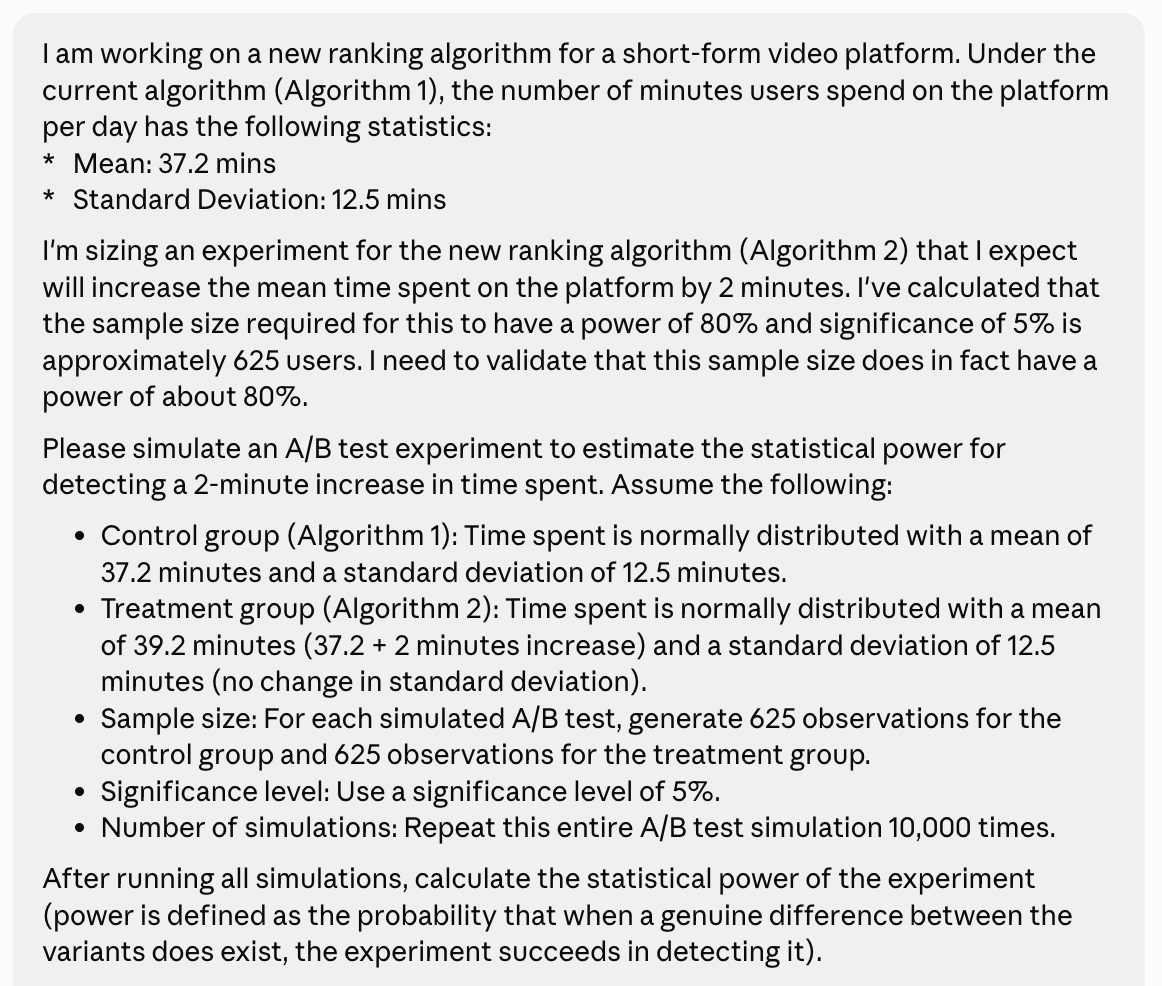

And Claude returned the following:
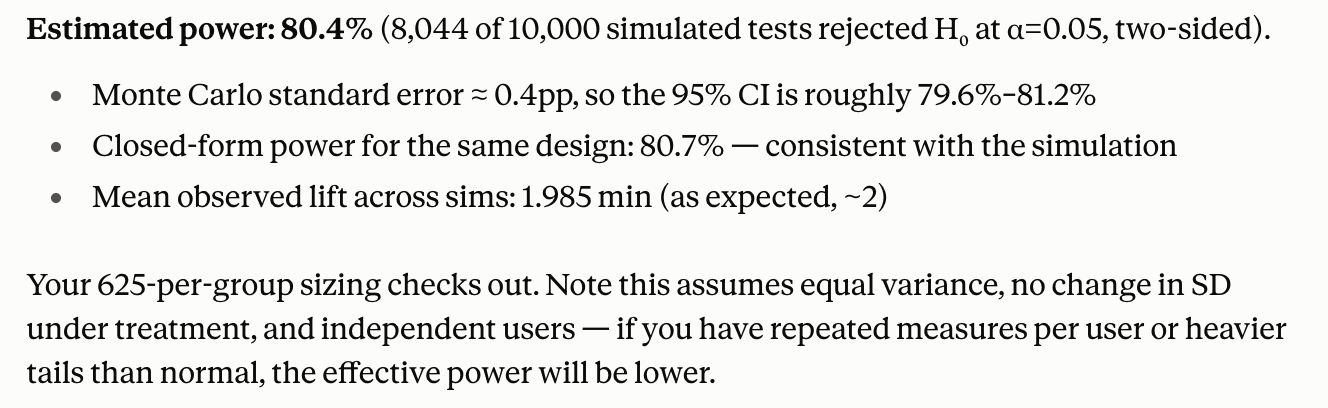

Claude estimates the power of this experiment to be ~80.4%, which validates the selected sample size of 625 users from part (a) fulfilling an ~80% power level.

c) (8 points) Ask Claude to generate a plot of how the power of the experiment changes for various sample size N from N = 100 to N = 2000. Show that plot and provide an interpretation. Again, ask Claude to perform an experiment instead of using formulas. If you wanted to achieve a power of 90%, approximately how many samples would you need?

Claude was prompted with the following:
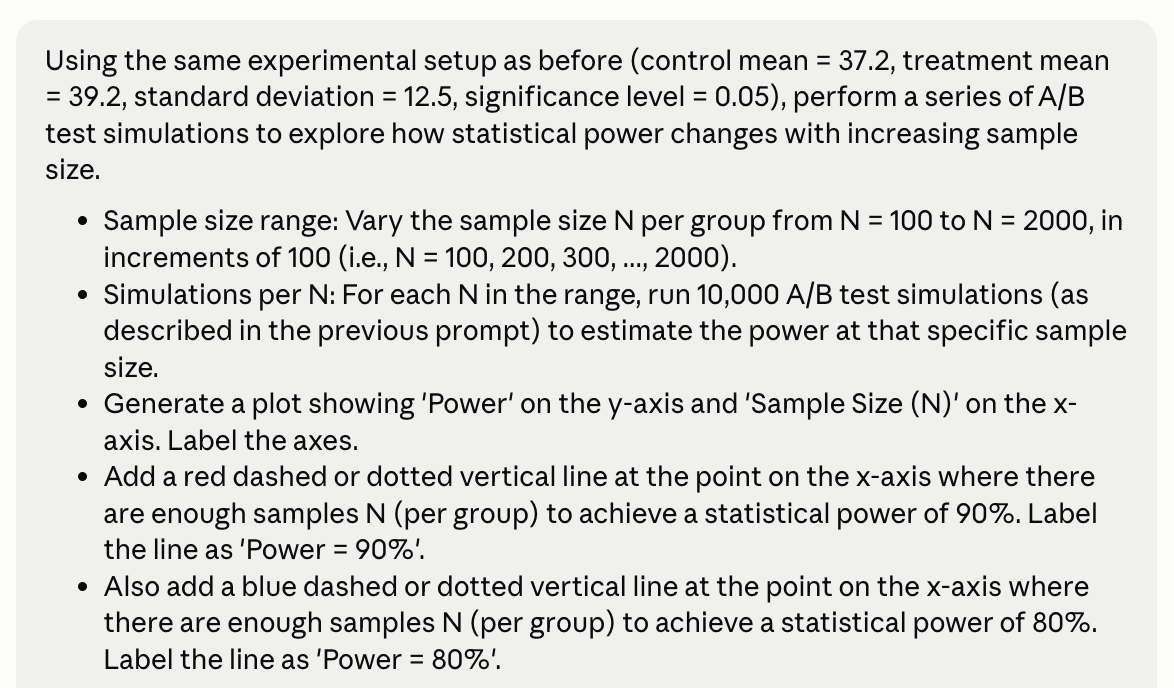

And Claude returned the following plot:
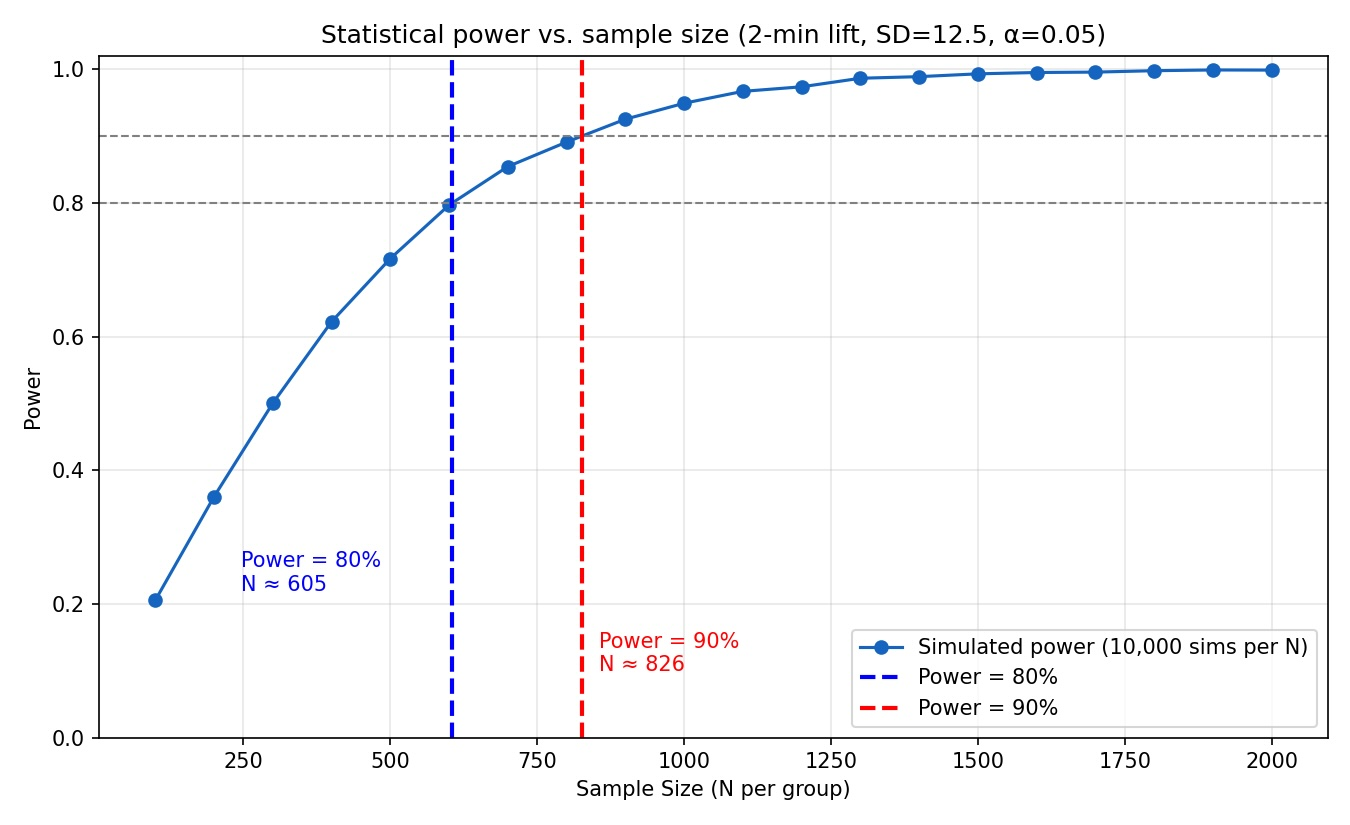

Looking at the power curve, we can see that at N = 100 per group, the power is only ~20% - meaning that 80% of the time, the experiment would show that the new algorithm does nothing (a false negative, as we know it adds 2 minutes). At N = ~600-625 per group, we reach 80% power. For 200 more users per group, at N = 826, we get 10 more percentage points of power; depending on how long it takes to gather these 200 users per group, it could be worthwhile or not worthwhile to run a larger sample size in the experiment. The rest of the power curve shows diminishing returns in power for equivalent increases in sample size, telling us that the impact is not worth the extra work of increasing the sample size. 80% or 90% power is sufficient to get us a successful experiment.

To achieve a statistical power of 90%, we need approximately N = 826 samples - about 200 samples more than the sample size of the experiment we've already designed.

d) (3 points) Is it possible to achieve a power of 100%? Why or why not?

No; from the plot in part (c), we can observe that the power curve approaches but never truly reaches 100%.

Again, power is defined as the probability that, when a genuine difference between the original algorithm group and the new algorithm group really does exist, the experiment succeeds in detecting it.
Intuitively, no matter how many samples N we take, we can never fully exclude the possibility that the control group (the original algorithm) randomly happens to sample high and the treatment group (the new algorithm) randomly happens to sample low, leading to the experiment not detecting the 2-min increase effect.

Theoretically, an infinite sample size of N = $\infty$ could lead to 100% power, as could zero variance or an infinitely large minimum detectable effect; but as these are impossible under realistic experiment constraints, it is impossible to achieve a power of 100%.